In [1]:
import nilearn as nl
import numpy as np
import matplotlib
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import openpyxl as xl

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix, plot_contrast_matrix
from nilearn.glm.first_level import FirstLevelModel
from nilearn.masking import compute_epi_mask, apply_mask, unmask
from nilearn.image import index_img, resample_to_img, math_img, mean_img, get_data
from nilearn.plotting import plot_stat_map, show
from nilearn import image, masking
from nilearn import plotting
from nilearn.datasets import load_mni152_brain_mask
from pandas import read_excel

from nilearn.glm.second_level import SecondLevelModel
from scipy.stats import norm

from nilearn.glm import threshold_stats_img

In [2]:
#
#   Constants
#

epidata_dir = "./_testData/fmri"
confounds_dir = "../_testData/confounds/"

testSubject = 221
# Define subjects
participants = [49]#, 58, 95, 115, 127, 181, 186, 190, 191, 200, 201] + list(range(206, 238)) + list(range(239, 254))
#exclude subj 238, see paper

# currently random onsets and durations for each sentence to generate the code!
onsets = [44.7, 49.3, 53.8, 58.1, 62.9, 68.5, 73.4, 78.2, 82.9, 87.4, 92.1, 96.5, 101.3, 105.9, 110.5, 115.0, 119.6, 124.1, 
          128.9, 133.4, 138.2, 142.8, 147.3, 152.0, 156.7, 161.5, 166.1, 170.7, 175.3, 180.1, 184.6, 189.2, 194.0, 198.7, 
          203.5, 208.0, 212.6, 217.1, 222.0, 226.5, 231.1, 235.9, 240.4, 245.0, 249.8, 254.3, 259.1, 263.7, 268.3, 273.0, 
          277.8, 282.5, 287.3, 292.0, 296.5, 301.1, 305.9, 310.4, 315.0, 319.8, 324.3, 328.9, 333.6, 338.4, 343.1, 347.8, 
          352.4, 357.0, 366.8, 379.5, 388.2, 400.0, 412.8, 422.4, 430.0, 438.5]

durations = [4.6, 4.5, 4.3, 4.8, 5.6, 4.9, 4.8, 4.7, 4.5, 4.7, 4.4, 4.8, 4.6, 4.6, 4.5, 4.6, 4.5, 4.8, 4.5, 4.8, 4.6, 
             4.5, 4.7, 4.7, 4.8, 4.6, 4.6, 4.6, 4.8, 4.5, 4.6, 4.8, 4.7, 4.8, 4.5, 4.6, 4.5, 4.9, 4.5, 4.6, 4.8, 4.5, 
             4.6, 4.8, 4.5, 4.8, 4.6, 4.6, 4.7, 4.8, 4.7, 4.8, 4.7, 4.5, 4.6, 4.8, 4.5, 4.6, 4.8, 4.5, 4.6, 4.7, 4.8, 
             4.7, 4.7, 4.6, 4.6, 9.8, 12.7, 8.7, 11.8, 12.8, 9.6, 7.6, 8.5, 7.6]

textValueFileDF = pd.read_excel("foundationScores/shapessocial_transcript_segment_MFT_MAC.xlsx")

sentenceValues = textValueFileDF[['MAC_a_fairness_virtue',
                               'MAC_a_group_virtue',
                               'MAC_a_deference_virtue',
                               'MAC_a_heroism_virtue',
                               'MAC_a_reciprocity_virtue',
                               'MAC_a_family_virtue',
                               'MAC_a_property_virtue']]



In [3]:
sentenceValues

,MAC_a_fairness_virtue,MAC_a_group_virtue,MAC_a_deference_virtue,MAC_a_heroism_virtue,MAC_a_reciprocity_virtue,MAC_a_family_virtue,MAC_a_property_virtue
0,0.044444,0.081587,0.040000,0.035714,0.059091,0.108974,0.026316
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.072917,0.000000,0.000000,0.056818,0.000000,0.050000,0.050000
3,0.000000,0.062696,0.103448,0.000000,0.068463,0.000000,0.020000
4,0.000000,0.045833,0.021875,0.000000,0.039855,0.152142,0.018519
...,...,...,...,...,...,...,...
71,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
72,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
73,0.139803,0.219736,0.208983,0.108108,0.146372,0.284181,0.035714
74,0.182449,0.175644,0.188730,0.031915,0.072727,0.225236,0.027027


In [4]:
#
#   Helper functions
#

def load_epi_data_social(sub):
    # Load MRI file (in Nifti format)
    epi_in = os.path.join(epidata_dir,"sub-%03d_task-shapessocial_space-MNI152NLin2009cAsym_res-native_desc-preproc_bold.nii" % (sub))
    epi_data_social = nib.load(epi_in)
    print("Loading data from %s" % (epi_in))
    return epi_data_social

def load_epi_data_physical(sub):
    # Load MRI file (in Nifti format)
    epi_in = os.path.join(epidata_dir,"sub-%03d_task-shapesphysical_space-MNI152NLin2009cAsym_res-native_desc-preproc_bold.nii" % (sub))
    epi_data_physical = nib.load(epi_in)
    print("Loading data from %s" % (epi_in))
    return epi_data_physical


In [14]:
events

,trial_type,onset,duration
0,MAC_a_family_virtue,44.7,4.6
1,baseline,49.3,4.5
2,MAC_a_fairness_virtue,53.8,4.3
3,MAC_a_deference_virtue,58.1,4.8
4,MAC_a_family_virtue,62.9,5.6
...,...,...,...
71,baseline,400.0,12.8
72,baseline,412.8,9.6
73,MAC_a_family_virtue,422.4,7.6
74,MAC_a_family_virtue,430.0,8.5


In [5]:
#
#   Data transform
#

epi_data_socialNIFTI = load_epi_data_social(testSubject)

events = pd.DataFrame( {"trial_type":range(0,len(sentenceValues)),"onset":onsets,"duration":durations})
fname1 = "sub-%03d_task-shapessocial_desc-confounds_regressors.tsv" % testSubject
confoundsAll = confounds_dir + fname1

df = pd.read_csv(confoundsAll, sep='\t')
confound_file1 = df[['csf', 'white_matter', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']].to_numpy()

# dtermine the max column for each row
max_column = sentenceValues.idxmax(axis=1)

# Determine rows where all 7 columns are 0.00 (to two decimal places)
all_zero_mask = (sentenceValues.round(2) == 0).all(axis=1)
# Replace column name with "baseline" for those rows
max_column[all_zero_mask] = "baseline"

max_columns_list = max_column.tolist()

events['trial_type'] = max_columns_list

Loading data from ./testData/fmri/sub-221_task-shapessocial_space-MNI152NLin2009cAsym_res-native_desc-preproc_bold.nii


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/first_level/first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


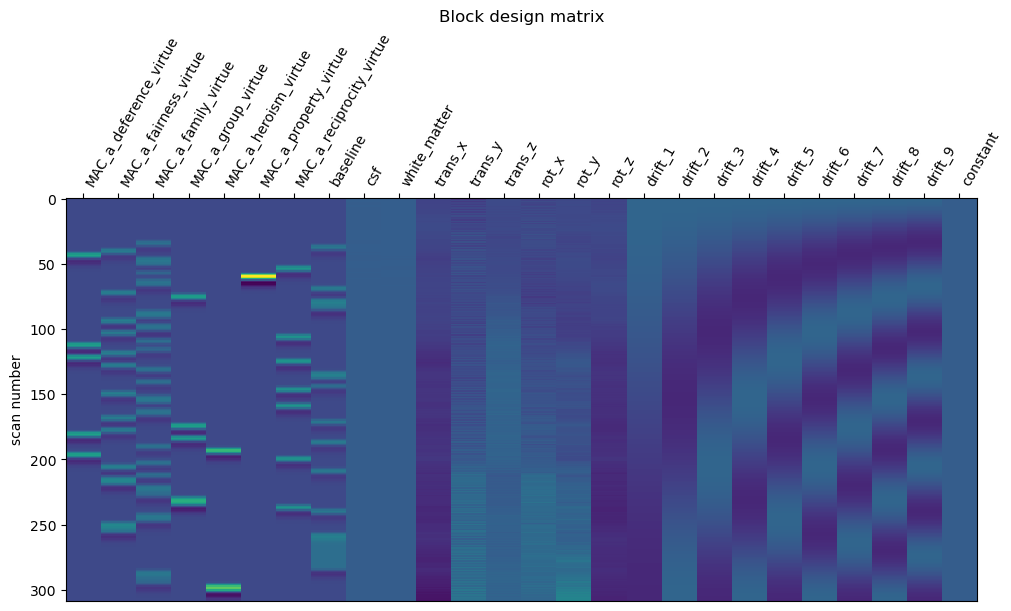

In [6]:

# Make an average
mean_img = image.mean_img(epi_data_socialNIFTI, copy_header=True)
mask = masking.compute_epi_mask(mean_img, lower_cutoff=0.2, upper_cutoff=0.85, opening=3, connected=True)

# Clean and smooth data
epi_data_socialNIFTI = image.clean_img(epi_data_socialNIFTI, standardize=False)
epi_data_socialNIFTI = image.smooth_img(epi_data_socialNIFTI, 6.0)

# get fdata
epi_data_social = epi_data_socialNIFTI.get_fdata()

frame_times = (
    np.arange(epi_data_social.shape[3] ) * 1.5
)

#baseline first level model

X_base = make_first_level_design_matrix(
    frame_times,
    events,
    add_regs=confound_file1,
    add_reg_names=['csf', 'white_matter', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z'],
    hrf_model='glover',
)

FM1 = FirstLevelModel(mask_img=mask)
FM1 = FM1.fit(epi_data_socialNIFTI, design_matrices=X_base)


#contrast first level model

# Let's compare it to the unmodulated block design
fig, (ax1) = plt.subplots(
    figsize=(10, 6), nrows=1, ncols=1, constrained_layout=True
)

plot_design_matrix(X_base, axes=ax1)
ax1.set_title("Block design matrix", fontsize=12)

plt.savefig("design_matrix.jpg", dpi=300, bbox_inches='tight')

plt.show()


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/_utils/helpers.py:94: UserWarning: Contrasts will be padded with 19 column(s) of zeros.
  return func(*args, **kwargs)


<Axes: label='conditions'>

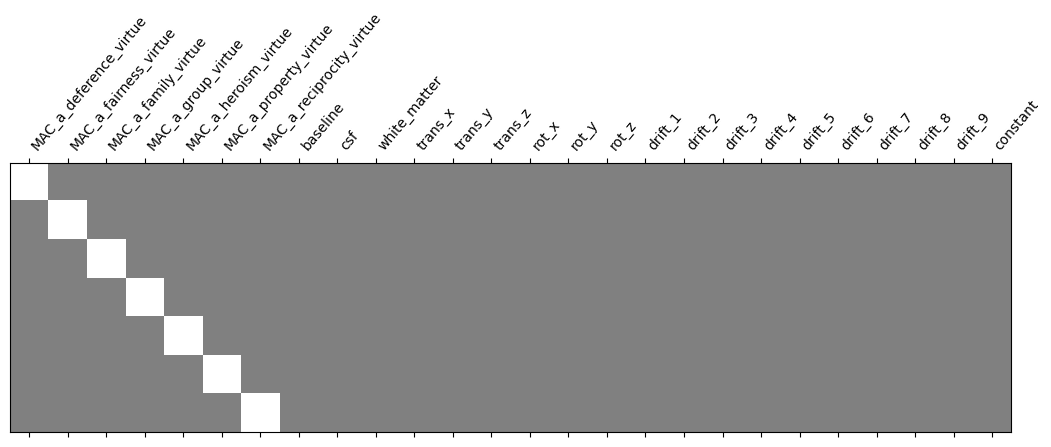

In [7]:
## create contrast image F test (which voxels significant in any of the 7 foundations)
contrast_val = np.eye(7)
plot_contrast_matrix(contrast_val, X_base)


In [11]:

contrast_name = "F_contrast"

z_map = FM1.compute_contrast(
    contrast_val,
    stat_type='F',
    output_type="z_score"  # Can be ‘z_score’, ‘stat’, ‘p_value’, ‘effect_size’, ‘effect_variance’ or ‘all’
)

# Apply mask to z_map
masked_data = apply_mask(z_map, mask)      
z_map_masked = unmask(masked_data, mask)  

# save contrast image (to be used at second level)
z_map_masked.to_filename("F_contrast.nii.gz")

# determine for each moral foundations, where is more activation for that foundation vs an average of the other 6

#foundation 1
c1 = np.array([1, -1/6, -1/6, -1/6, -1/6, -1/6, -1/6])  # exact -1/6
z_map_foundation1 = FM1.compute_contrast(c1, stat_type='t', output_type='z_score')

#foundation 1
c2 = np.array([-1/6, 1, -1/6, -1/6, -1/6, -1/6, -1/6])  # exact -1/6
z_map_foundation2 = FM1.compute_contrast(c2, stat_type='t', output_type='z_score')

#foundation 1
c3 = np.array([-1/6, -1/6, 1, -1/6, -1/6, -1/6, -1/6])  # exact -1/6
z_map_foundation3 = FM1.compute_contrast(c3, stat_type='t', output_type='z_score')

#foundation 1
c4 = np.array([-1/6, -1/6, -1/6, 1, -1/6, -1/6, -1/6])  # exact -1/6
z_map_foundation4 = FM1.compute_contrast(c4, stat_type='t', output_type='z_score')

#foundation 1
c5 = np.array([-1/6, -1/6, -1/6, -1/6, 1, -1/6, -1/6])  # exact -1/6
z_map_foundation5 = FM1.compute_contrast(c5, stat_type='t', output_type='z_score')

#foundation 1
c6 = np.array([-1/6, -1/6, -1/6, -1/6, -1/6, 1, -1/6])  # exact -1/6
z_map_foundation6 = FM1.compute_contrast(c6, stat_type='t', output_type='z_score')

#foundation 1
c7 = np.array([-1/6, -1/6, -1/6, -1/6, -1/6, -1/6, 1])  # exact -1/6
z_map_foundation7 = FM1.compute_contrast(c7, stat_type='t', output_type='z_score')

z_map_foundation1.to_filename("z_map_foundation1_vsOther6.nii.gz")
z_map_foundation2.to_filename("z_map_foundation2_vsOther6.nii.gz")
z_map_foundation3.to_filename("z_map_foundation3_vsOther6.nii.gz")
z_map_foundation4.to_filename("z_map_foundation4_vsOther6.nii.gz")
z_map_foundation5.to_filename("z_map_foundation5_vsOther6.nii.gz")
z_map_foundation6.to_filename("z_map_foundation6_vsOther6.nii.gz")
z_map_foundation7.to_filename("z_map_foundation7_vsOther6.nii.gz")

In [12]:
#foundation 1
c1 = np.array([1, 0, 0, 0, 0, 0, 0, -1])  # exact -1/6
z_map_foundation1vsbase = FM1.compute_contrast(c1, stat_type='t', output_type='z_score')

#foundation 1
c2 = np.array([0, 1, 0, 0, 0, 0, 0, -1])  # exact -1/6
z_map_foundation2vsbase = FM1.compute_contrast(c2, stat_type='t', output_type='z_score')

#foundation 1
c3 = np.array([0, 0, 1, 0, 0, 0, 0, -1])  # exact -1/6
z_map_foundation3vsbase = FM1.compute_contrast(c3, stat_type='t', output_type='z_score')

#foundation 1
c4 = np.array([0, 0, 0, 1, 0, 0, 0, -1])  # exact -1/6
z_map_foundation4vsbase = FM1.compute_contrast(c4, stat_type='t', output_type='z_score')

#foundation 1
c5 = np.array([0, 0, 0, 0, 1, 0, 0, -1])  # exact -1/6
z_map_foundation5vsbase = FM1.compute_contrast(c5, stat_type='t', output_type='z_score')

#foundation 1
c6 = np.array([0, 0, 0, 0, 0, 1, 0, -1])  # exact -1/6
z_map_foundation6vsbase = FM1.compute_contrast(c6, stat_type='t', output_type='z_score')

#foundation 1
c7 = np.array([0, 0, 0, 0, 0, 0, 1, -1])  # exact -1/6
z_map_foundation7vsbase = FM1.compute_contrast(c7, stat_type='t', output_type='z_score')

z_map_foundation1vsbase.to_filename("z_map_foundation1_moral_vs_baseline.nii.gz")
z_map_foundation2vsbase.to_filename("z_map_foundation2_moral_vs_baseline.nii.gz")
z_map_foundation3vsbase.to_filename("z_map_foundation3_moral_vs_baseline.nii.gz")
z_map_foundation4vsbase.to_filename("z_map_foundation4_moral_vs_baseline.nii.gz")
z_map_foundation5vsbase.to_filename("z_map_foundation5_moral_vs_baseline.nii.gz")
z_map_foundation6vsbase.to_filename("z_map_foundation6_moral_vs_baseline.nii.gz")
z_map_foundation7vsbase.to_filename("z_map_foundation7_moral_vs_baseline.nii.gz")

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/contrasts.py:115: UserWarning: t contrasts should be of length P=26, but it has length 8. The rest of the contrast was padded with zeros.
  reg = regression_result[label_].Tcontrast(con_val)


In [13]:
# based on t maps rather than thresholded maps, minimum statistic conjunction
# based on: 
# Thomas Nichols, Matthew Brett, Jesper Andersson, Tor Wager, Jean-Baptiste Poline,
# Valid conjunction inference with the minimum statistic, NeuroImage, Volume 25, Issue 3, 2005

min_stat_map = image.math_img(
    "np.minimum.reduce((img1, img2, img3, img4, img5, img6, img7))",
    img1=z_map_foundation1vsbase,
    img2=z_map_foundation2vsbase,
    img3=z_map_foundation3vsbase,
    img4=z_map_foundation4vsbase,
    img5=z_map_foundation5vsbase,
    img6=z_map_foundation6vsbase,
    img7=z_map_foundation7vsbase,
)
min_stat_map.to_filename('minimum_stat_conjunction.nii.gz')